In [1]:
import numpy as np
import pandas as pd

import os
import sys

import anndata as ad
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# sys.path.append('./sim')
# sys.path.append('./sim')

from sim2 import *

In [18]:
linear_counts_df, linear_cell_meta, linear_sample_meta, linear_gene_meta, linear_pseudobulk_df, linear_composition_df = simulate_timeseries_topology(
    topology="linear",
    n_timepoints=4,
    reps_per_time=3,
    cells_per_sample=300,
    seed=42,
    model='negbin',
    dispersion_theta = 7,
    dynamic_strength = 0.95,
    shared_strength = 0.95,
)

In [19]:
bif_counts_df, bif_cell_meta, bif_sample_meta, bif_gene_meta, bif_pseudobulk_df, bif_composition_df = simulate_timeseries_topology(
    topology="bifurcation",
    n_timepoints=4,
    reps_per_time=3,
    cells_per_sample=300,
    seed=42,
    model='negbin',
    dispersion_theta = 7,
    dynamic_strength = 0.95,
    shared_strength = 0.95,
)

In [20]:
cyc_counts_df, cyc_cell_meta, cyc_sample_meta, cyc_gene_meta, cyc_pseudobulk_df, cyc_composition_df = simulate_timeseries_topology(
    topology="cyclic",
    n_timepoints=4,
    reps_per_time=3,
    cells_per_sample=300,
    seed=42,
    model='negbin',
    dispersion_theta = 7,
    dynamic_strength = 0.95,
    shared_strength = 0.95,
)

In [21]:
def create_anndata(counts_df, cell_meta, gene_meta):
    adata = ad.AnnData(counts_df.T.values)
    adata.layers['counts'] = adata.X.copy()
    adata.obs_names = list(cell_meta.index)
    adata.var_names = list(gene_meta.index)
    adata.obs = adata.obs.join(cell_meta.loc[adata.obs_names])
    adata.var = adata.var.join(gene_meta.loc[adata.var_names])
    
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    sc.tl.pca(adata, svd_solver='arpack')
    sc.pp.neighbors(adata, n_neighbors=20, n_pcs=30)
    sc.tl.umap(adata)
    return adata

In [22]:
linear_an = create_anndata(linear_counts_df, linear_cell_meta, linear_gene_meta)
bif_an = create_anndata(bif_counts_df, bif_cell_meta, bif_gene_meta)
cyc_an = create_anndata(cyc_counts_df, cyc_cell_meta, cyc_gene_meta)

/data1/home/jyj/miniconda3/envs/gtra_test/lib/python3.8/site-packages/anndata/_core/anndata.py:864: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  names = self._prep_dim_index(names, "obs")
/data1/home/jyj/miniconda3/envs/gtra_test/lib/python3.8/site-packages/anndata/_core/anndata.py:887: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  names = self._prep_dim_index(names, "var")
/data1/home/jyj/miniconda3/envs/gtra_test/lib/python3.8/site-packages/anndata/_core/anndata.py:788: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)
/data1/home/jyj/miniconda3/envs/gtra_test/lib/python3.8/site-packages/anndata/_core/anndata.py:788: UserWarning: 
AnnData expects .var.index to contain strings,

/data1/home/jyj/miniconda3/envs/gtra_test/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data1/home/jyj/miniconda3/envs/gtra_test/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


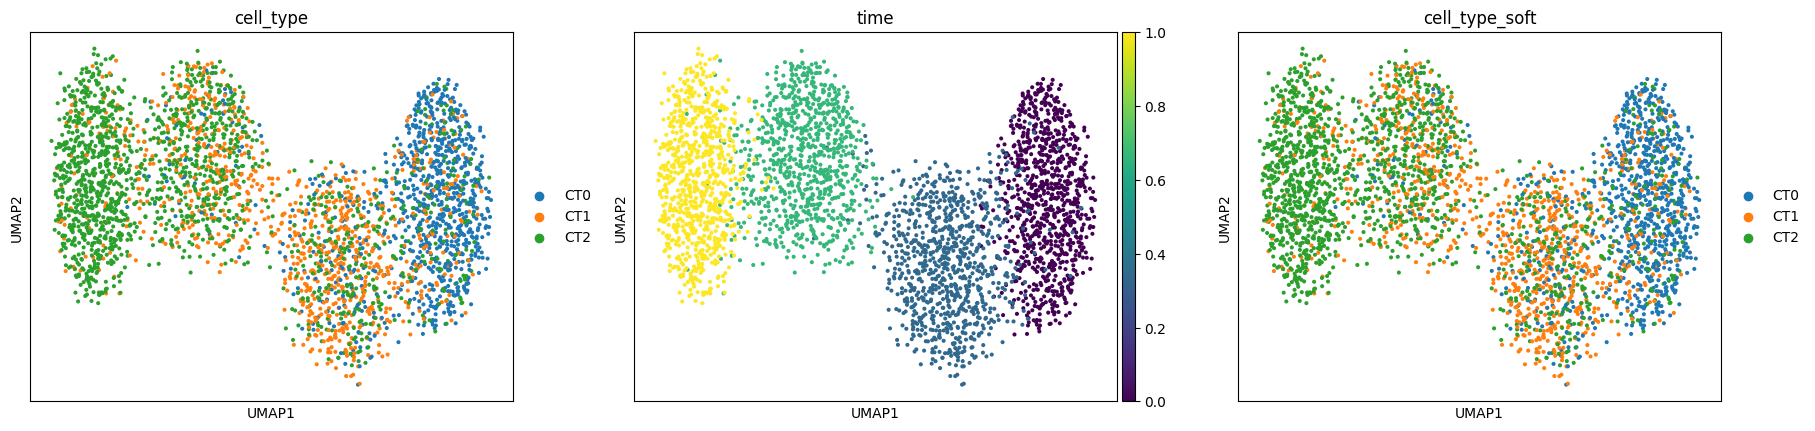

In [23]:
sc.pl.umap(linear_an, color=['cell_type','time','cell_type_soft'])

/data1/home/jyj/miniconda3/envs/gtra_test/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data1/home/jyj/miniconda3/envs/gtra_test/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


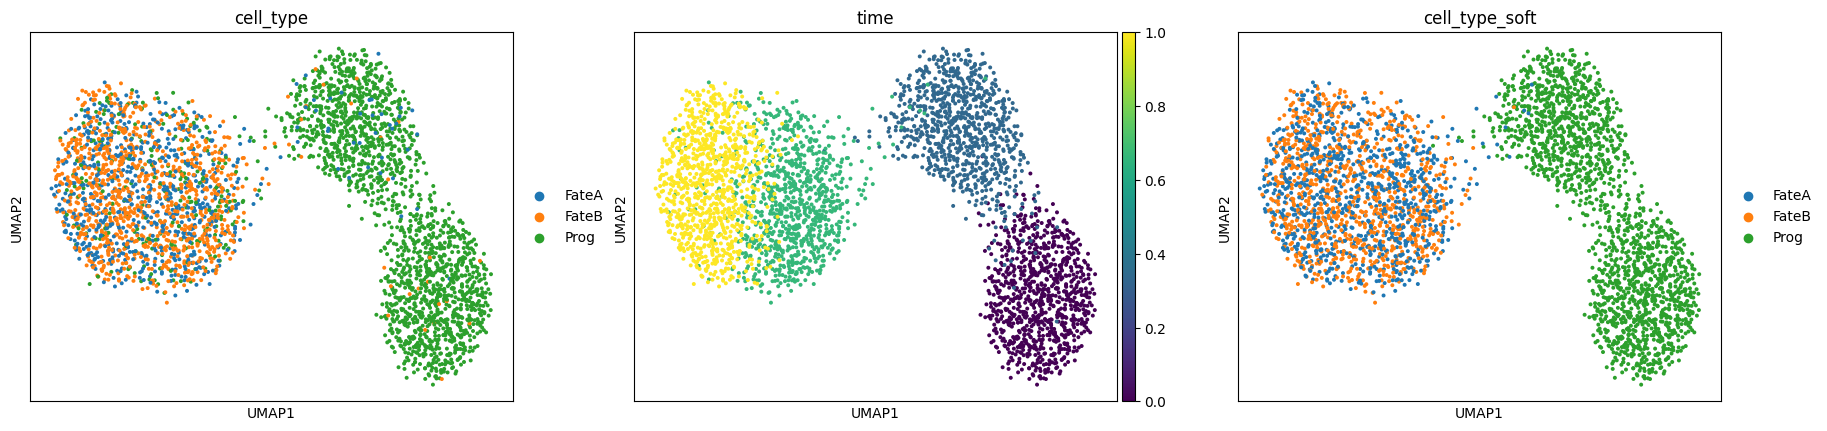

In [24]:
sc.pl.umap(bif_an, color=['cell_type','time','cell_type_soft'])

/data1/home/jyj/miniconda3/envs/gtra_test/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data1/home/jyj/miniconda3/envs/gtra_test/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


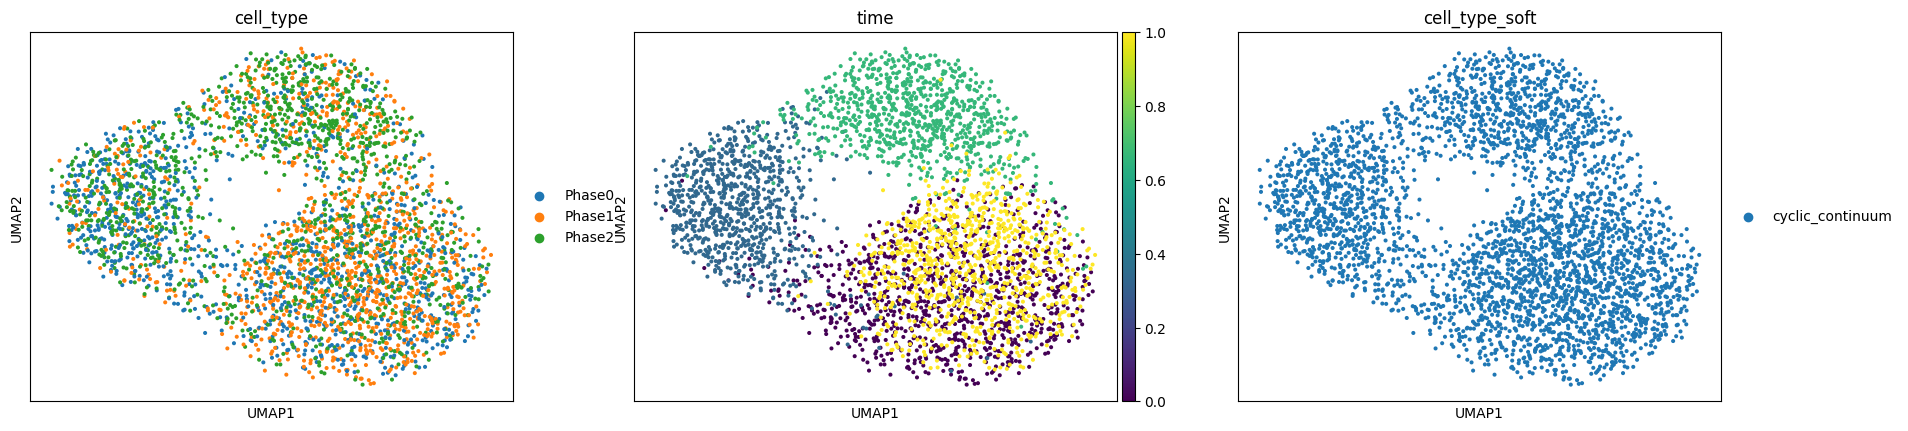

In [25]:
sc.pl.umap(cyc_an, color=['cell_type','time','cell_type_soft'])

In [134]:
bif_cell_meta.columns

Index(['cell_id', 'sample_id', 'time', 'time_idx', 'replicate', 'cell_type',
       'topology', 'sample_branch', 'tau', 'branch_progress', 'wA', 'wB',
       'cell_type_soft'],
      dtype='object')

In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_gene_cell_heatmap(
    counts_df,
    cell_meta,
    gene_meta,
    mode="linear",
    dynamic_amp_thresh=1.0,
    use_zscore=False,
    figsize=(7, 4)
):
    """
    counts_df: rows=genes, cols=cells
    cell_meta: must contain cell_id, tau (and optionally sample_branch)
    gene_meta: must contain gene_id, peak_time, dynamic_amp
    """

    # ----------------------------
    # 0. copy + string normalize
    # ----------------------------
    counts_df = counts_df.copy()
    counts_df.index = counts_df.index.astype(str)     # gene ids
    counts_df.columns = counts_df.columns.astype(str) # cell ids

    cm = cell_meta.copy()
    gm = gene_meta.copy()

    cm["cell_id"] = cm["cell_id"].astype(str)
    gm["gene_id"] = gm["gene_id"].astype(str)

    # ----------------------------
    # 1. cell ordering
    # ----------------------------
    if mode == "linear":
        order_cells = (
            cm.sort_values("time_idx")["cell_id"]
            .tolist()
        )

    elif mode == "bifurcation":
        order_cells = (
            cm.sort_values(["sample_branch", "tau"])["cell_id"]
            .tolist()
        )

    elif mode == "cyclic":
        # cell_meta에는 보통 phase가 없을 수 있으니 tau 우선 사용
        sort_col = "phase" if "phase" in cm.columns else "tau"
        order_cells = (
            cm.sort_values('tau')["cell_id"]
            .tolist()
        )

    else:
        raise ValueError("mode must be 'linear', 'bifurcation', or 'cyclic'")

    # ----------------------------
    # 2. gene filtering + ordering
    # ----------------------------
    if mode != "cyclic":
        gm = gm.query("dynamic_amp > @dynamic_amp_thresh").dropna(subset=["peak_time"])

        order_genes = (
            gm.sort_values("peak_time")["gene_id"]
            .tolist()
        )
    else:
        # gm  = gm.query("dynamic_amp > 1.0").dropna(subset=["phase"])
        # cyc_mask = (
        #     gm['program'].eq("cyclic_shared") |
        #     gm["program"].str.startswith("dynamic_phase",na=False)
        # )
        
        cyc_mask = (
            gm['program'].eq("cyclic_shared")
         
        )
        
        gm = gm.loc[cyc_mask].copy()
        order_genes  = gm.sort_values("phase")["gene_id"].tolist()



    # ----------------------------
    # 3. intersection
    # ----------------------------
    order_cells = [c for c in order_cells if c in counts_df.columns]
    order_genes = [g for g in order_genes if g in counts_df.index]

    print(f"matched cells: {len(order_cells)}")
    print(f"matched genes: {len(order_genes)}")

    if len(order_cells) == 0:
        raise ValueError("No matched cells. Check counts_df.columns vs cell_meta['cell_id']")
    if len(order_genes) == 0:
        raise ValueError("No matched genes. Check counts_df.index vs gene_meta['gene_id']")
    
    # ----------------------------
    # 4. subset matrix
    # counts_df = genes x cells
    # ----------------------------
    X = counts_df.loc[order_genes, order_cells]

    # log scale
    X = np.log1p(X)

    # optional row-wise z-score
    if use_zscore:
        row_mean = X.mean(axis=1)
        row_std = X.std(axis=1).replace(0, 1)
        X = X.sub(row_mean, axis=0).div(row_std, axis=0)

    print("X shape:", X.shape)

    # ----------------------------
    # 5. plot
    # ----------------------------
    plt.figure(figsize=figsize)
    sns.heatmap(X, cmap="viridis", xticklabels=False, yticklabels=False)
    plt.title(f"{mode} simulation")
    plt.xlabel("cell")
    plt.ylabel("gene")
    plt.tight_layout()
    plt.show()

matched cells: 3471
matched genes: 240
X shape: (240, 3471)


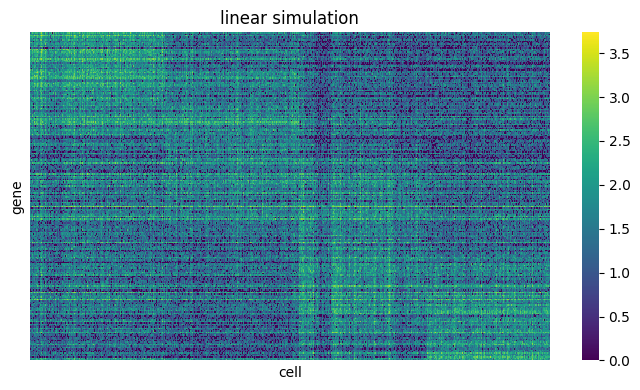

In [11]:
plot_gene_cell_heatmap(linear_counts_df, linear_cell_meta, linear_gene_meta, 
                       mode="linear",dynamic_amp_thresh=0.0,use_zscore=False)

matched cells: 3653
matched genes: 226
X shape: (226, 3653)


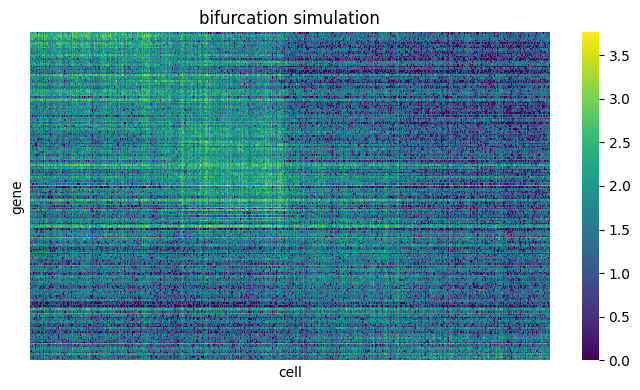

In [12]:
plot_gene_cell_heatmap(bif_counts_df, bif_cell_meta, bif_gene_meta, mode="bifurcation",use_zscore=False)

matched cells: 3502
matched genes: 80
X shape: (80, 3502)


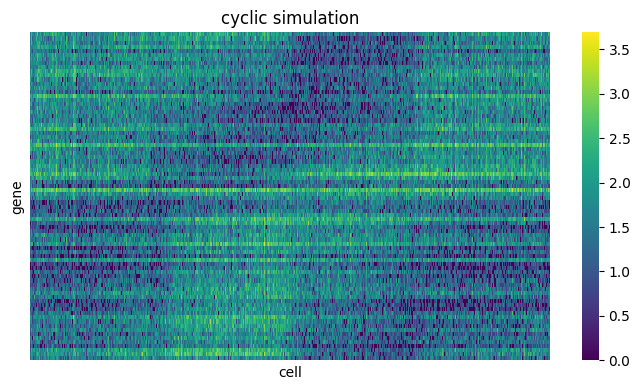

In [13]:
plot_gene_cell_heatmap(cyc_counts_df, cyc_cell_meta, cyc_gene_meta, mode="cyclic",
                       dynamic_amp_thresh=0.0,use_zscore=False)

In [226]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cyclic_heatmap(
    counts_df,
    cell_meta,
    gene_meta,
    cell_id_col="cell_id",
    gene_id_col="gene_id",
    cell_phase_col="phase",
    gene_phase_col="peak_time",   # 있으면 사용, 없으면 program만 사용
    program_col="program",
    figsize=(12, 7),
    use_log=True,
):
    counts = counts_df.copy()
    cm = cell_meta.copy()
    gm = gene_meta.copy()

    counts.index = counts.index.astype(str)
    counts.columns = counts.columns.astype(str)
    cm[cell_id_col] = cm[cell_id_col].astype(str)
    gm[gene_id_col] = gm[gene_id_col].astype(str)

    # -------------------------
    # 1. cell ordering
    # -------------------------
    ordered_cells = (
        cm.sort_values(cell_phase_col)[cell_id_col].astype(str).tolist()
    )
    ordered_cells = [c for c in ordered_cells if c in counts.columns]

    # -------------------------
    # 2. gene subset
    # -------------------------
    keep_programs = [
        "cyclic_shared",
        "phase0_marker",
        "phase1_marker",
        "phase2_marker",
        "dynamic_phase0",
        "dynamic_phase1",
        "dynamic_phase2",
    ]
    gm2 = gm[gm[program_col].isin(keep_programs)].copy()
    gm2 = gm2[gm2[gene_id_col].isin(counts.index)].copy()

    # -------------------------
    # 3. gene ordering
    # -------------------------
    if gene_phase_col in gm2.columns and gm2[gene_phase_col].notna().sum() > 0:
        # peak_time이 있으면 원형 순서로 사용
        gm2 = gm2.sort_values(gene_phase_col)
    else:
        # 없으면 program 기반 정렬
        program_order = {
            "phase0_marker": 0,
            "dynamic_phase0": 1,
            "cyclic_shared": 2,
            "phase1_marker": 3,
            "dynamic_phase1": 4,
            "phase2_marker": 5,
            "dynamic_phase2": 6,
        }
        gm2["program_rank"] = gm2[program_col].map(program_order).fillna(999)
        gm2 = gm2.sort_values(["program_rank", gene_id_col])

    ordered_genes = gm2[gene_id_col].astype(str).tolist()

    # -------------------------
    # 4. matrix
    # -------------------------
    mat = counts.loc[ordered_genes, ordered_cells]

    if use_log:
        mat_plot = np.log1p(mat)
        title = "cyclic simulation heatmap (log scale)"
    else:
        mat_plot = mat.copy()
        title = "cyclic simulation heatmap"

    # -------------------------
    # 5. plot
    # -------------------------
    plt.figure(figsize=figsize)
    sns.heatmap(
        mat_plot,
        cmap="viridis",
        xticklabels=False,
        yticklabels=False,
        cbar=True
    )
    plt.title(title)
    plt.xlabel("cell (ordered by phase)")
    plt.ylabel("gene (ordered by cyclic program / phase)")
    plt.tight_layout()
    plt.show()

    return mat_plot, gm2, cm

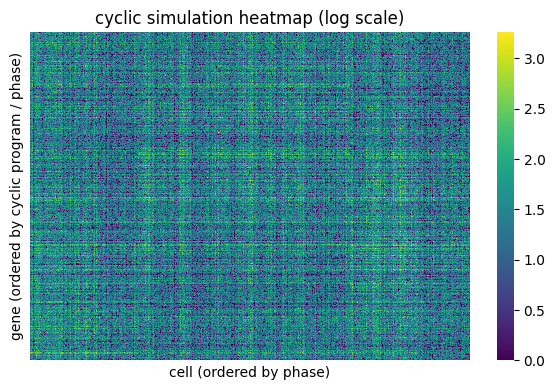

In [237]:

mat_plot, gm_used, cm_used = plot_cyclic_heatmap(
    counts_df=cyc_counts_df,
    cell_meta=cyc_cell_meta,
    gene_meta=cyc_gene_meta,
    cell_id_col="cell_id",
    gene_id_col="gene_id",
    cell_phase_col="cell_type_soft",
    gene_phase_col="phase",   # 없으면 자동으로 program 정렬
    program_col="program",
    figsize=(6,4),
    use_log=True,
)

In [238]:
cyc_gene_meta

,gene_id,program,preferred_cell_type,baseline,marker_effect,dynamic_amp,sigma,phase,peak_time
0,G0,cyclic_shared,None,1.853905,2.273112,2.888859,0.213258,2.334475,NaN
1,G1,cyclic_shared,None,1.934819,2.526237,4.003635,0.164647,1.186494,NaN
2,G2,cyclic_shared,None,2.063006,3.593845,1.885553,0.246604,1.228337,NaN
3,G3,cyclic_shared,None,3.155504,3.694834,2.324847,0.251560,2.576413,NaN
4,G4,cyclic_shared,None,2.836945,2.375633,2.094239,0.151980,3.012266,NaN
...,...,...,...,...,...,...,...,...,...
375,G375,dynamic_phase2,Phase2,1.745328,2.354678,2.140888,0.202270,2.804748,NaN
376,G376,dynamic_phase2,Phase2,3.744046,2.355615,2.118155,0.237193,5.987720,NaN
377,G377,dynamic_phase2,Phase2,2.460965,2.279886,2.021293,0.150685,4.089063,NaN
378,G378,dynamic_phase2,Phase2,3.797632,3.056046,4.898148,0.187428,0.728214,NaN


In [229]:
cyc_cell_meta.columns

Index(['cell_id', 'sample_id', 'time', 'time_idx', 'replicate', 'cell_type',
       'topology', 'sample_branch', 'tau', 'branch_progress', 'wA', 'wB',
       'cell_type_soft'],
      dtype='object')

In [230]:
cyc_an.var.columns

Index(['gene_id', 'program', 'preferred_cell_type', 'baseline',
       'marker_effect', 'dynamic_amp', 'sigma', 'phase', 'peak_time'],
      dtype='object')

In [225]:
cyc_an.var['program'].value_counts()

program
cyclic_shared     80
phase0_marker     60
phase1_marker     60
phase2_marker     60
dynamic_phase0    40
dynamic_phase1    40
dynamic_phase2    40
Name: count, dtype: int64

In [117]:
cyc_gene_meta

,gene_id,program,preferred_cell_type,baseline,marker_effect,dynamic_amp,sigma,phase,peak_time
0,G0,cyclic_shared,None,1.853905,2.273112,2.888859,0.213258,2.334475,NaN
1,G1,cyclic_shared,None,1.934819,2.526237,4.003635,0.164647,1.186494,NaN
2,G2,cyclic_shared,None,2.063006,3.593845,1.885553,0.246604,1.228337,NaN
3,G3,cyclic_shared,None,3.155504,3.694834,2.324847,0.251560,2.576413,NaN
4,G4,cyclic_shared,None,2.836945,2.375633,2.094239,0.151980,3.012266,NaN
...,...,...,...,...,...,...,...,...,...
375,G375,dynamic_phase2,Phase2,1.745328,2.354678,2.140888,0.202270,2.804748,NaN
376,G376,dynamic_phase2,Phase2,3.744046,2.355615,2.118155,0.237193,5.987720,NaN
377,G377,dynamic_phase2,Phase2,2.460965,2.279886,2.021293,0.150685,4.089063,NaN
378,G378,dynamic_phase2,Phase2,3.797632,3.056046,4.898148,0.187428,0.728214,NaN
